In [1]:
from dataclasses import dataclass, field
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import copy
import torch

In [2]:
@dataclass
class Pin:
    local_pos: np.ndarray
    net: str

@dataclass
class Component:
    id: str
    pos: np.ndarray
    theta: float = 0.0
    half_size: np.ndarray = field(default_factory=lambda: np.array([2.5, 2.5]))
    pins: list = field(default_factory=list)
    fixed: bool = False

def rot(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

def pin_world(component, pin):
    return component.pos + rot(component.theta) @ pin.local_pos

def rebuild_nets(components):
    nets = {}
    for cid, comp in components.items():
        for pi, pin in enumerate(comp.pins):
            nets.setdefault(pin.net, []).append((cid, pi))
    return nets

In [3]:
board = np.array([[0, 0], [40, 0], [40, 25], [0, 25]], float)

rng = np.random.default_rng(7)
components = {}

def add(cid, hs, pin_specs, theta=0.0):
    components[cid] = Component(
        cid,
        rng.uniform([4, 4], [36, 21]),          # random start
        theta=theta,
        half_size=np.array(hs, float),
        pins=[Pin(np.array(lp, float), net) for lp, net in pin_specs],
    )

# MCU
add("U1", (3.0, 3.0), [
    ((-2.5,  2.5), "3V3"),  ((-2.5,  1.5), "GND"),
    ((-2.5,  0.5), "GPIO1"),((-2.5, -0.5), "GPIO2"),
    ((-2.5, -1.5), "GPIO3"),((-2.5, -2.5), "GPIO4"),
    (( 2.5,  2.5), "USB_DP"),(( 2.5,  1.5), "USB_DM"),
    (( 2.5,  0.5), "SWDIO"), (( 2.5, -0.5), "SWCLK"),
    (( 0.5, -2.5), "XTAL1"), (( 1.5, -2.5), "XTAL2"),
])

# 3.3V regulator: 5V in, 3V3 out
add("U2", (1.5, 1.2), [
    ((-1.5,  0.5), "5V"), ((-1.5, -0.5), "GND"), ((1.5, 0.0), "3V3"),
])

# decoupling caps
add("C1", (0.7, 0.4), [((-0.7, 0), "3V3"), ((0.7, 0), "GND")])
add("C2", (0.7, 0.4), [((-0.7, 0), "3V3"), ((0.7, 0), "GND")])
add("C3", (0.9, 0.5), [((-0.9, 0), "5V"),  ((0.9, 0), "GND")])

# crystal + load caps
add("Y1", (1.4, 0.6), [((-1.4, 0), "XTAL1"), ((1.4, 0), "XTAL2")])
add("C4", (0.6, 0.4), [((-0.6, 0), "XTAL1"), ((0.6, 0), "GND")])
add("C5", (0.6, 0.4), [((-0.6, 0), "XTAL2"), ((0.6, 0), "GND")])

# two LED chains: GPIO -> R -> LED -> GND
add("R1", (1.0, 0.4), [((-1.0, 0), "GPIO1"), ((1.0, 0), "LED1_A")])
add("D1", (0.8, 0.4), [((-0.8, 0), "LED1_A"), ((0.8, 0), "GND")])
add("R2", (1.0, 0.4), [((-1.0, 0), "GPIO2"), ((1.0, 0), "LED2_A")])
add("D2", (0.8, 0.4), [((-0.8, 0), "LED2_A"), ((0.8, 0), "GND")])

# USB series resistors
add("R3", (1.0, 0.4), [((-1.0, 0), "USB_DP"), ((1.0, 0), "USB_DP_C")])
add("R4", (1.0, 0.4), [((-1.0, 0), "USB_DM"), ((1.0, 0), "USB_DM_C")])

# connectors
add("J_USB", (2.5, 1.4), [
    ((-1.8, -0.9), "5V"), ((-1.8, -0.3), "USB_DP_C"),
    ((-1.8,  0.3), "USB_DM_C"), ((-1.8, 0.9), "GND"),
])
add("J_DEBUG", (2.2, 1.4), [
    ((-1.5, -0.9), "SWDIO"), ((-1.5, -0.3), "SWCLK"),
    ((-1.5,  0.3), "GND"),   ((-1.5,  0.9), "3V3"),
])

components["J_USB"].pos   = np.array([38.0, 18.0]); components["J_USB"].fixed   = True
components["J_DEBUG"].pos = np.array([38.0,  6.0]); components["J_DEBUG"].fixed = True

rebuild_nets(components)

{'3V3': [('U1', 0), ('U2', 2), ('C1', 0), ('C2', 0), ('J_DEBUG', 3)],
 'GND': [('U1', 1),
  ('U2', 1),
  ('C1', 1),
  ('C2', 1),
  ('C3', 1),
  ('C4', 1),
  ('C5', 1),
  ('D1', 1),
  ('D2', 1),
  ('J_USB', 3),
  ('J_DEBUG', 2)],
 'GPIO1': [('U1', 2), ('R1', 0)],
 'GPIO2': [('U1', 3), ('R2', 0)],
 'GPIO3': [('U1', 4)],
 'GPIO4': [('U1', 5)],
 'USB_DP': [('U1', 6), ('R3', 0)],
 'USB_DM': [('U1', 7), ('R4', 0)],
 'SWDIO': [('U1', 8), ('J_DEBUG', 0)],
 'SWCLK': [('U1', 9), ('J_DEBUG', 1)],
 'XTAL1': [('U1', 10), ('Y1', 0), ('C4', 0)],
 'XTAL2': [('U1', 11), ('Y1', 1), ('C5', 0)],
 '5V': [('U2', 0), ('C3', 0), ('J_USB', 0)],
 'LED1_A': [('R1', 1), ('D1', 0)],
 'LED2_A': [('R2', 1), ('D2', 0)],
 'USB_DP_C': [('R3', 1), ('J_USB', 1)],
 'USB_DM_C': [('R4', 1), ('J_USB', 2)]}

In [4]:
ids = list(components)
hs = torch.tensor(np.array([components[c].half_size for c in ids]), dtype=torch.float32)
pos = torch.tensor(np.array([components[c].pos for c in ids]),
                   dtype=torch.float32, requires_grad=True)
theta = torch.tensor([components[c].theta for c in ids],
                     dtype=torch.float32, requires_grad=True)

fixed = torch.tensor([components[c].fixed for c in ids])
fixed_pos = pos.detach().clone()
fixed_theta = theta.detach().clone()

net_pins = []
for members in rebuild_nets(components).values():
    if len(members) < 2:
        continue
    net_pins.append([(ids.index(cid),
                      torch.tensor(components[cid].pins[pi].local_pos, dtype=torch.float32))
                     for cid, pi in members])

def pin_pos(i, off):
    c, s = torch.cos(theta[i]), torch.sin(theta[i])
    return pos[i] + torch.stack([c * off[0] - s * off[1],
                                 s * off[0] + c * off[1]])

def hs_eff():
    # AABB half-size of the rotated box -- differentiable in theta
    c, s = torch.cos(theta).abs(), torch.sin(theta).abs()
    return torch.stack([c * hs[:, 0] + s * hs[:, 1],
                        c * hs[:, 1] + s * hs[:, 0]], dim=1)


In [5]:
def hpwl(components):
    total = 0.0
    for members in rebuild_nets(components).values():
        if len(members) < 2:
            continue
        pts = np.array([pin_world(components[cid], components[cid].pins[pi]) for cid, pi in members])
        total += np.ptp(pts[:, 0]) + np.ptp(pts[:, 1])
    return total
hpwl(components)

np.float64(363.2500039196011)

In [6]:
# rect is on (lo, hi)
def project_position(c, lo, hi):
    c.pos = np.clip(c.pos, lo + c.half_size, hi - c.half_size)

In [7]:
def attractive(components, nets):
    F = {cid: np.zeros(2) for cid in components}
    for members in nets.values():
        if len(members) < 2:
            continue
        pts = [pin_world(components[cid], components[cid].pins[pi]) for cid, pi in members]
        ctr = np.mean(pts, axis=0)
        for (cid, _), p in zip(members, pts):
            F[cid] += ctr - p
    return F
attractive(components, rebuild_nets(components))

{'U1': array([-17.44609446, -48.25108208]),
 'U2': array([-10.25145826,  17.50519197]),
 'C1': array([16.79433783, -9.1711973 ]),
 'C2': array([35.66800057, -7.39214638]),
 'C3': array([-5.23783702,  2.42248055]),
 'Y1': array([8.77311011, 7.84935993]),
 'C4': array([14.87220468,  3.08925815]),
 'C5': array([2.82267554, 0.01732851]),
 'R1': array([-13.54961393,   2.80722594]),
 'D1': array([ 5.22862001, -8.60972731]),
 'R2': array([11.26228279,  5.0262198 ]),
 'D2': array([-6.79174334, 10.11241123]),
 'R3': array([26.20975854,  6.97320736]),
 'R4': array([12.43293466, -0.06553484]),
 'J_USB': array([-41.79521271, -11.49525   ]),
 'J_DEBUG': array([-38.991965  ,  29.18225446])}

In [8]:
# TODO loop attract and repulse together?
def repulsive(components, k=30.0, slop=0.4):
    F = {cid: np.zeros(2) for cid in components}
    ids = list(components)
    for i in range(len(ids)):
        a = components[ids[i]]
        for j in range(i + 1, len(ids)):
            b = components[ids[j]]
            dx, dy = b.pos - a.pos
            ox = a.half_size[0] + b.half_size[0] + slop - abs(dx)
            oy = a.half_size[1] + b.half_size[1] + slop - abs(dy)
            if ox <= 0 or oy <= 0:
                continue
            if ox < oy:
                push = np.array([np.sign(dx or 1) * ox * k, 0.0])
            else:
                push = np.array([0.0, np.sign(dy or 1) * oy * k])
            F[ids[i]] -= push
            F[ids[j]] += push
    return F
repulsive(components)

{'U1': array([  0.        , -67.20936318]),
 'U2': array([0., 0.]),
 'C1': array([0., 0.]),
 'C2': array([0., 0.]),
 'C3': array([0., 0.]),
 'Y1': array([0., 0.]),
 'C4': array([0., 0.]),
 'C5': array([0., 0.]),
 'R1': array([  0.       , -50.2575788]),
 'D1': array([ 0.        , 67.20936318]),
 'R2': array([0., 0.]),
 'D2': array([0., 0.]),
 'R3': array([0., 0.]),
 'R4': array([0., 0.]),
 'J_USB': array([ 0.       , 50.2575788]),
 'J_DEBUG': array([0., 0.])}

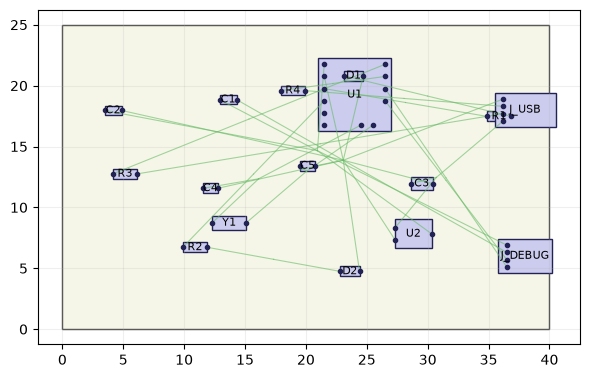

In [9]:
def draw(components, board, title=""):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.add_patch(patches.Polygon(board, facecolor="#f6f6e8", edgecolor="#444"))
    # draw ratsnest as star
    for net, members in rebuild_nets(components).items():
        if len(members) < 2:
            continue
        pts = [pin_world(components[cid], components[cid].pins[pi]) for cid, pi in members]
        ctr = np.mean(pts, axis=0)  # centroid
        for p in pts: ax.plot([p[0], ctr[0]], [p[1], ctr[1]], "-", color="#6b6", alpha=0.6, lw=0.8)
    # draw components
    for cid, c in components.items():
        box = np.array([[-1, -1], [1, -1], [1, 1], [-1, 1]]) * c.half_size
        corners = (rot(c.theta) @ box.T).T + c.pos
        ax.add_patch(patches.Polygon(corners, facecolor="#cce", edgecolor="#225"))
        ax.text(*c.pos, cid, ha="center", va="center", fontsize=8)
        for p in c.pins:
            ax.plot(*pin_world(c, p), "o", color="#225", markersize=3)
    ax.autoscale_view()
    ax.grid(alpha=0.2)
    plt.show()

draw(components, board)

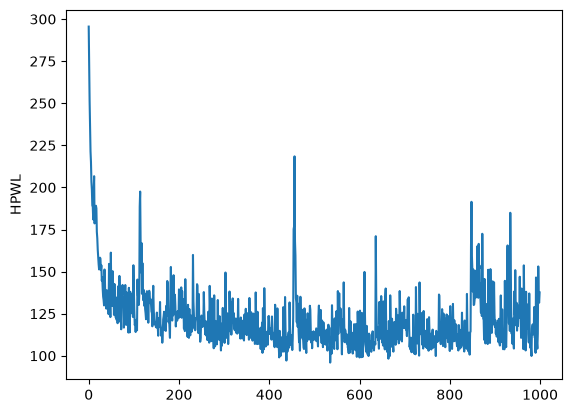

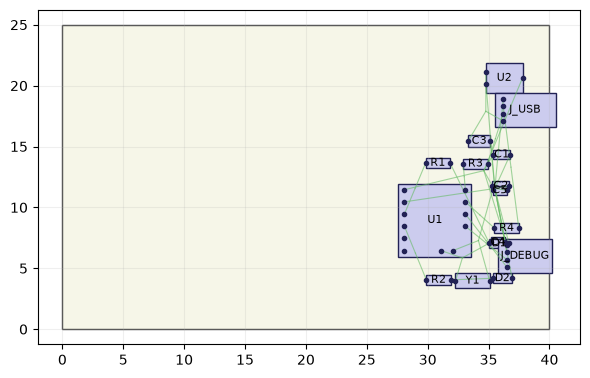

In [10]:
def step(components, dt=0.05):
    nets = rebuild_nets(components)
    Fa = attractive(components, nets)
    Fr = repulsive(components)
    for cid, c in components.items():
        if c.fixed:
            continue
        c.pos = c.pos + dt * (Fa[cid] + Fr[cid])
        project_position(c, board[0], board[2])

# randomize pos (keep fixed parts where they are)
rng = np.random.default_rng(0)
components_copy = copy.deepcopy(components)
for c in components_copy.values():
    if not c.fixed:
        c.pos = rng.uniform(board[0] + 4, board[2] - 4)

history = []
for _ in range(1000):
    step(components_copy)
    history.append(hpwl(components_copy))

plt.plot(history); plt.ylabel("HPWL"); plt.show()
draw(components_copy, board)


In [11]:
# helpers: copy tensor positions + rotations back into Component objects, then print + draw
def snapshot():
    snap = copy.deepcopy(components)
    p = pos.detach().numpy()
    t = theta.detach().numpy()
    for i, cid in enumerate(ids):
        snap[cid].pos = p[i].astype(float)
        snap[cid].theta = float(t[i])
    return snap

def show(title=""):
    snap = snapshot()
    print(f"{title}: HPWL = {hpwl(snap):.2f}")
    draw(snap, board, title)


before (WL only): HPWL = 363.25


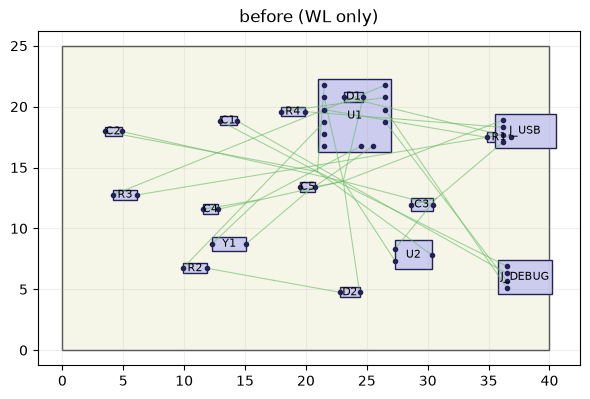

after (WL only): HPWL = 48.29


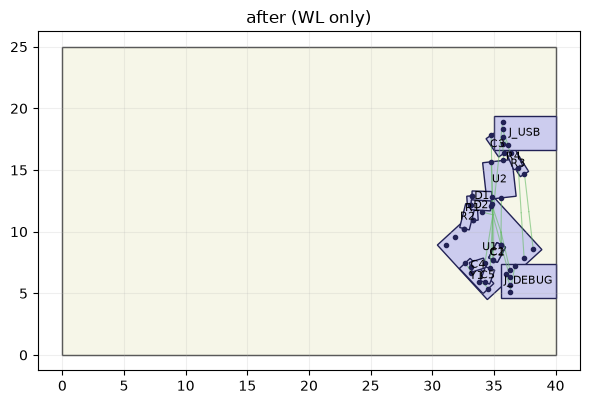

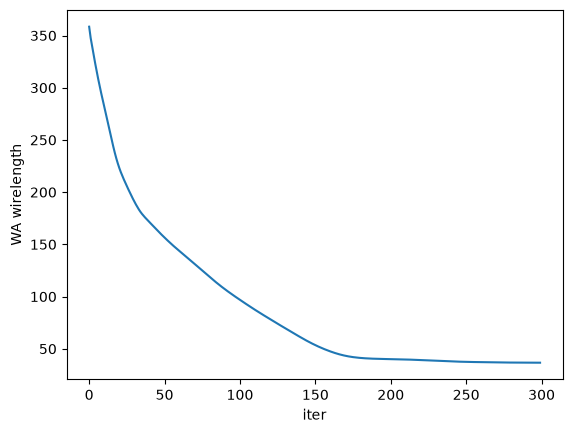

In [12]:
lo = torch.tensor(board[0], dtype=torch.float32)
hi = torch.tensor(board[2], dtype=torch.float32)

def wa_wirelength(gamma=1.0):
    total = 0.0
    for members in net_pins:
        pts = torch.stack([pin_pos(i, off) for i, off in members])
        for d in range(2):
            x = pts[:, d]
            total = total + (x * torch.softmax(x / gamma, 0)).sum() \
                          - (x * torch.softmax(-x / gamma, 0)).sum()
    return total

show("before (WL only)")

opt = torch.optim.Adam([{"params": [pos], "lr": 0.2},
                        {"params": [theta], "lr": 0.05}])
wl_hist = []
for it in range(300):
    opt.zero_grad()
    loss = wa_wirelength()
    loss.backward()
    opt.step()
    with torch.no_grad():
        pos.data[fixed] = fixed_pos[fixed]
        theta.data[fixed] = fixed_theta[fixed]
        h = hs_eff()
        pos.data = torch.max(torch.min(pos, hi - h), lo + h)
    wl_hist.append(loss.item())

show("after (WL only)")
plt.plot(wl_hist); plt.xlabel("iter"); plt.ylabel("WA wirelength"); plt.show()


In [13]:
M = 64  # bins per axis

bx = torch.linspace(lo[0], hi[0], M + 1)
by = torch.linspace(lo[1], hi[1], M + 1)
bin_area = (bx[1] - bx[0]) * (by[1] - by[0])

def density_map():
    h = hs_eff()   # rotation-aware footprint
    ox = (torch.minimum(pos[:, 0:1] + h[:, 0:1], bx[None, 1:])
        - torch.maximum(pos[:, 0:1] - h[:, 0:1], bx[None, :-1])).clamp(min=0)   # (n, M)
    oy = (torch.minimum(pos[:, 1:2] + h[:, 1:2], by[None, 1:])
        - torch.maximum(pos[:, 1:2] - h[:, 1:2], by[None, :-1])).clamp(min=0)   # (n, M)
    rho = torch.einsum("ni,nj->ij", ox, oy) / bin_area    # (M, M), area fraction per bin
    return rho


In [14]:
def electro_energy(rho):
    q = (rho - 1.0).clamp(min=0)              # only over-capacity density is charge
    q = q - q.mean()                          # neutralize for the periodic solve
    fx = torch.fft.fftfreq(M) * 2 * np.pi
    k2 = fx[:, None]**2 + fx[None, :]**2
    k2[0, 0] = 1.0                            # avoid div-by-zero at DC (q has no DC anyway)
    phi = torch.fft.ifft2(torch.fft.fft2(q) / k2).real
    return 0.5 * (q * phi).sum()

before (WL + density): HPWL = 363.25


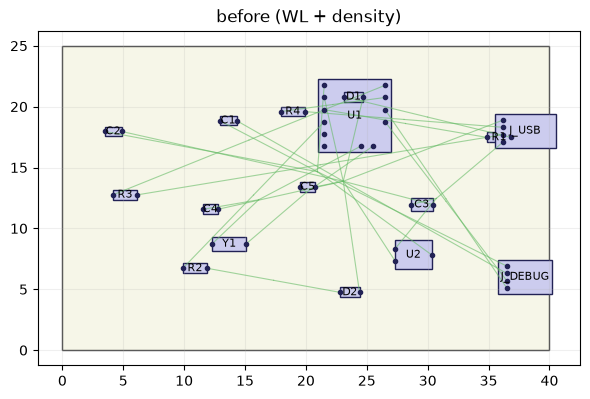

it    0  WL   358.45  lam*density     0.01  snap   0.00  lam 0.0010  overflow   2.95
it  100  WL    98.50  lam*density     1.53  snap   0.00  lam 0.0198  overflow   7.97
it  200  WL    51.21  lam*density     1.56  snap   0.00  lam 0.3804  overflow   1.65
it  300  WL    53.86  lam*density     0.25  snap   0.07  lam 2.0493  overflow   0.24
it  400  WL    52.61  lam*density     0.59  snap   0.06  lam 2.4382  overflow   0.38
it  500  WL    52.68  lam*density     0.32  snap   0.05  lam 2.7418  overflow   0.27
after (WL + density + snap): HPWL = 66.82


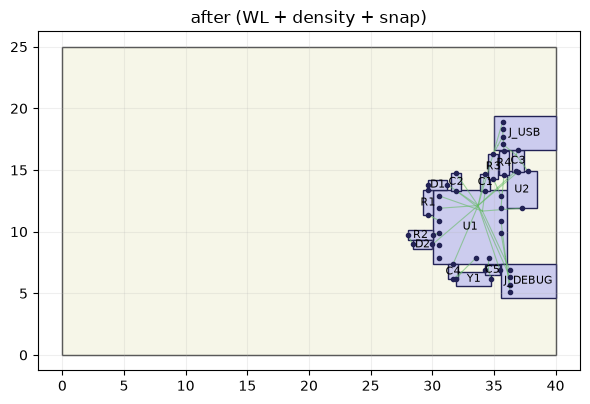

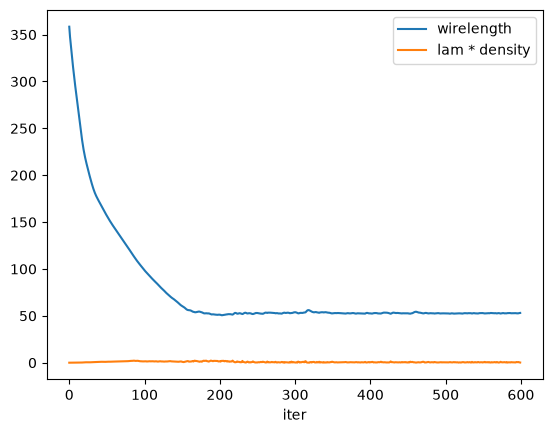

In [15]:
# reset to original placement (positions AND rotations)
pos.data = torch.tensor(np.array([components[c].pos for c in ids]), dtype=torch.float32)
theta.data = torch.tensor([components[c].theta for c in ids], dtype=torch.float32)
show("before (WL + density)")

opt = torch.optim.Adam([{"params": [pos], "lr": 0.2},
                        {"params": [theta], "lr": 0.05}])
lam, snap_w = 1e-3, 0.0
n_iters = 600
wl_hist, den_hist = [], []
for it in range(n_iters):
    opt.zero_grad()
    wl = wa_wirelength()
    den = lam * electro_energy(density_map())
    snap = snap_w * torch.sin(2 * theta).pow(2).sum()   # zero at every 90 degrees
    loss = wl + den + snap
    loss.backward()
    opt.step()
    with torch.no_grad():
        pos.data[fixed] = fixed_pos[fixed]
        theta.data[fixed] = fixed_theta[fixed]
        h = hs_eff()
        pos.data = torch.max(torch.min(pos, hi - h), lo + h)
    with torch.no_grad():   # overflow = total overlapped area; grow lam only while it exists
        overflow = ((density_map() - 1.0).clamp(min=0).sum() * bin_area).item()
    if overflow > 0.5:
        lam *= 1.03           # overlap remains: press harder
    elif overflow < 0.2:
        lam *= 0.97           # legal: relax so wirelength re-tightens
    if it > 0.4 * n_iters:                 # let parts rotate freely early, park them late
        snap_w = min(snap_w + 0.02, 5.0)
    wl_hist.append(wl.item()); den_hist.append(den.item())
    if it % 100 == 0:
        print(f"it {it:4d}  WL {wl.item():8.2f}  lam*density {den.item():8.2f}  "
              f"snap {snap.item():6.2f}  lam {lam:.4f}  overflow {overflow:6.2f}")

# legalize rotation: hard snap to nearest 90
with torch.no_grad():
    theta.data = torch.round(theta / (np.pi / 2)) * (np.pi / 2)
    theta.data[fixed] = fixed_theta[fixed]
    h = hs_eff()
    pos.data = torch.max(torch.min(pos, hi - h), lo + h)

show("after (WL + density + snap)")
plt.plot(wl_hist, label="wirelength")
plt.plot(den_hist, label="lam * density")
plt.xlabel("iter"); plt.legend(); plt.show()


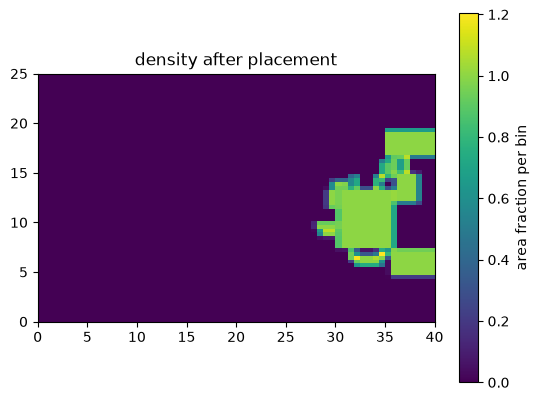

In [16]:
# final density map -- bright spots = remaining overlap
plt.imshow(density_map().detach().T, origin="lower",
           extent=[board[0][0], board[2][0], board[0][1], board[2][1]])
plt.colorbar(label="area fraction per bin")
plt.title("density after placement")
plt.show()
